# Proyek Klasifikasi Gambar: EuroSAT RGB
- **Nama:** Agung Trisutaji Aprian
- **Email:** agung.trisutaji.aprian@gmail.com
- **ID Dicoding:** agungtrisutaji

## Import Semua Packages/Library yang Digunakan

Cell ini memuat library yang dibutuhkan untuk persiapan dataset, mulai dari pembacaan TFDS, manipulasi file, validasi gambar, sampai penyimpanan ringkasan audit.

In [1]:
import hashlib
import json
import random
import re
import shutil
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow_datasets.image_classification import eurosat as tfds_eurosat
from PIL import Image, UnidentifiedImageError

## Data Preparation

### Setup Reproducibility dan Path

Seed dibuat tetap di angka `42` agar proses split dataset dapat direproduksi. Semua path menggunakan path relatif supaya notebook dapat dijalankan di environment lain tanpa bergantung pada lokasi lokal pribadi.

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_NAME = "eurosat/rgb"
DATASET_DIR = Path("dataset")
RAW_DIR = DATASET_DIR / "raw"
TRAIN_DIR = DATASET_DIR / "train"
VALIDATION_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"
AUDIT_DIR = Path("outputs") / "dataset_audit"
TFDS_DATA_DIR = Path("tfds_data")

for directory in [RAW_DIR, TRAIN_DIR, VALIDATION_DIR, TEST_DIR, AUDIT_DIR, TFDS_DATA_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

paths = {
    "raw": str(RAW_DIR),
    "train": str(TRAIN_DIR),
    "validation": str(VALIDATION_DIR),
    "test": str(TEST_DIR),
    "dataset_audit": str(AUDIT_DIR),
    "tfds_data": str(TFDS_DATA_DIR),
}

paths

{'raw': 'dataset\\raw',
 'train': 'dataset\\train',
 'validation': 'dataset\\validation',
 'test': 'dataset\\test',
 'dataset_audit': 'outputs\\dataset_audit',
 'tfds_data': 'tfds_data'}

### Data Loading

Dataset `eurosat/rgb` dimuat dari TensorFlow Datasets. Metadata dataset dipakai untuk mengambil nama kelas, jumlah kelas, split awal, shape gambar, dan dtype tanpa menuliskan daftar kelas secara manual. Jika URL bawaan TFDS sedang tidak dapat diakses, builder TFDS tetap digunakan dengan arsip RGB resmi dari Zenodo.

In [3]:
# URL bawaan TFDS untuk EuroSAT RGB kadang mengembalikan HTTP 403.
# Dataset tetap dimuat melalui builder TFDS, tetapi sumber ZIP RGB diarahkan ke mirror resmi Zenodo.
EUROSAT_RGB_ZENODO_URL = "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1"

for builder_config in tfds_eurosat.Eurosat.BUILDER_CONFIGS:
    if builder_config.name == "rgb":
        builder_config.download_url = EUROSAT_RGB_ZENODO_URL
        builder_config.subdir = "EuroSAT_RGB"
        break

# Download/load TFDS dapat memakan waktu pada eksekusi pertama.
dataset, dataset_info = tfds.load(
    DATASET_NAME,
    split="train",
    as_supervised=True,
    with_info=True,
    shuffle_files=False,
    data_dir=str(TFDS_DATA_DIR),
)

def to_snake_case(value: str) -> str:
    """Mengubah nama kelas TFDS menjadi nama folder yang konsisten."""
    value = re.sub(r"(.)([A-Z][a-z]+)", r"\1_\2", value)
    value = re.sub(r"([a-z0-9])([A-Z])", r"\1_\2", value)
    value = re.sub(r"[^a-zA-Z0-9]+", "_", value)
    return value.strip("_").lower()


label_feature = dataset_info.features["label"]
image_feature = dataset_info.features["image"]
class_names_original = list(label_feature.names)
class_names = [to_snake_case(class_name) for class_name in class_names_original]
initial_splits = {
    split_name: int(split_info.num_examples)
    for split_name, split_info in dataset_info.splits.items()
}

sample_image, sample_label = next(iter(tfds.as_numpy(dataset.take(1))))

expected_metadata = {
    "total_images": 27000,
    "num_classes": 10,
    "initial_split_names": ["train"],
    "image_shape": (64, 64, 3),
    "image_dtype": "uint8",
}

metadata_summary = {
    "dataset_name": DATASET_NAME,
    "total_images": int(dataset_info.splits["train"].num_examples),
    "num_classes": int(label_feature.num_classes),
    "class_names_original": class_names_original,
    "class_names": class_names,
    "initial_splits": initial_splits,
    "image_shape_from_metadata": tuple(image_feature.shape),
    "image_dtype_from_metadata": str(image_feature.dtype),
    "sample_image_shape": tuple(sample_image.shape),
    "sample_image_dtype": str(sample_image.dtype),
    "sample_label": int(sample_label),
}
metadata_validation = {
    "total_images_valid": metadata_summary["total_images"] == expected_metadata["total_images"],
    "num_classes_valid": metadata_summary["num_classes"] == expected_metadata["num_classes"],
    "initial_split_valid": sorted(metadata_summary["initial_splits"].keys()) == expected_metadata["initial_split_names"],
    "image_shape_valid": metadata_summary["sample_image_shape"] == expected_metadata["image_shape"],
    "image_dtype_valid": metadata_summary["sample_image_dtype"] == expected_metadata["image_dtype"],
}
metadata_summary["validation"] = metadata_validation

metadata_summary

{'dataset_name': 'eurosat/rgb',
 'total_images': 27000,
 'num_classes': 10,
 'class_names_original': ['AnnualCrop',
  'Forest',
  'HerbaceousVegetation',
  'Highway',
  'Industrial',
  'Pasture',
  'PermanentCrop',
  'Residential',
  'River',
  'SeaLake'],
 'class_names': ['annual_crop',
  'forest',
  'herbaceous_vegetation',
  'highway',
  'industrial',
  'pasture',
  'permanent_crop',
  'residential',
  'river',
  'sea_lake'],
 'initial_splits': {'train': 27000},
 'image_shape_from_metadata': (64, 64, 3),
 'image_dtype_from_metadata': "<dtype: 'uint8'>",
 'sample_image_shape': (64, 64, 3),
 'sample_image_dtype': 'uint8',
 'sample_label': 1,
 'validation': {'total_images_valid': True,
  'num_classes_valid': True,
  'initial_split_valid': True,
  'image_shape_valid': True,
  'image_dtype_valid': True}}

### Export TFDS ke Folder Raw

Data dari TFDS diekspor ke `dataset/raw/<class_name>/` dalam format JPEG RGB. Nama folder kelas diambil dari metadata TFDS lalu dibuat konsisten dengan format `snake_case`. Struktur folder per kelas memudahkan proses audit, split stratified, dan penggunaan ulang pada tahap modelling berikutnya.

In [4]:
def reset_directory(directory: Path) -> None:
    if directory.exists():
        shutil.rmtree(directory)
    directory.mkdir(parents=True, exist_ok=True)


for directory in [RAW_DIR, TRAIN_DIR, VALIDATION_DIR, TEST_DIR]:
    reset_directory(directory)

for class_name in class_names:
    (RAW_DIR / class_name).mkdir(parents=True, exist_ok=True)

raw_records = []
raw_class_counter = Counter()

# Proses export seluruh gambar dapat memakan waktu beberapa menit.
for image_index, (image, label) in enumerate(tfds.as_numpy(dataset)):
    label_id = int(label)
    class_name = class_names[label_id]
    raw_class_counter[class_name] += 1

    file_name = f"{class_name}_{raw_class_counter[class_name]:05d}.jpg"
    image_path = RAW_DIR / class_name / file_name
    Image.fromarray(image).convert("RGB").save(image_path, format="JPEG", quality=95)

    raw_records.append(
        {
            "image_index": image_index,
            "label_id": label_id,
            "class_name": class_name,
            "raw_path": str(image_path),
        }
    )

raw_records_df = pd.DataFrame(raw_records)
raw_distribution_df = (
    raw_records_df.groupby("class_name")
    .size()
    .reindex(class_names)
    .reset_index(name="raw_count")
)

raw_distribution_df

,class_name,raw_count
0,annual_crop,3000
1,forest,3000
2,herbaceous_vegetation,3000
3,highway,2500
4,industrial,2500
5,pasture,2000
6,permanent_crop,2500
7,residential,3000
8,river,2500
9,sea_lake,3000


### Data Preprocessing

#### Split Dataset

Dataset dibagi secara stratified per kelas menjadi 80% train, 10% validation, dan 10% test. Test set hanya disiapkan untuk evaluasi akhir dan tidak digunakan untuk training maupun tuning.

In [5]:
split_dirs = {
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}

for split_dir in split_dirs.values():
    for class_name in class_names:
        (split_dir / class_name).mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
split_records = []

for class_name in class_names:
    class_files = sorted((RAW_DIR / class_name).glob("*.jpg"))
    class_files = np.array(class_files, dtype=object)
    rng.shuffle(class_files)

    total_class_images = len(class_files)
    train_count = int(total_class_images * 0.8)
    validation_count = int(total_class_images * 0.1)

    split_file_map = {
        "train": class_files[:train_count],
        "validation": class_files[train_count : train_count + validation_count],
        "test": class_files[train_count + validation_count :],
    }

    for split_name, files in split_file_map.items():
        for source_path in files:
            target_path = split_dirs[split_name] / class_name / source_path.name
            shutil.copy2(source_path, target_path)
            split_records.append(
                {
                    "class_name": class_name,
                    "split": split_name,
                    "source_path": str(source_path),
                    "target_path": str(target_path),
                }
            )

split_records_df = pd.DataFrame(split_records)
split_distribution_df = (
    split_records_df.groupby(["class_name", "split"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=class_names, columns=["train", "validation", "test"], fill_value=0)
    .reset_index()
)

dataset_split_summary_df = raw_distribution_df.merge(
    split_distribution_df,
    on="class_name",
    how="left",
)
dataset_split_summary_df["total_after_split"] = dataset_split_summary_df[
    ["train", "validation", "test"]
].sum(axis=1)

dataset_split_summary_path = AUDIT_DIR / "dataset_split_summary.csv"
dataset_split_summary_df.to_csv(dataset_split_summary_path, index=False)

dataset_split_summary_df

,class_name,raw_count,train,validation,test,total_after_split
0,annual_crop,3000,2400,300,300,3000
1,forest,3000,2400,300,300,3000
2,herbaceous_vegetation,3000,2400,300,300,3000
3,highway,2500,2000,250,250,2500
4,industrial,2500,2000,250,250,2500
5,pasture,2000,1600,200,200,2000
6,permanent_crop,2500,2000,250,250,2500
7,residential,3000,2400,300,300,3000
8,river,2500,2000,250,250,2500
9,sea_lake,3000,2400,300,300,3000


### Audit Dataset

Audit dilakukan untuk memeriksa distribusi kelas sebelum dan sesudah split, resolusi gambar, mode warna, format file, gambar corrupt, duplikasi file dalam setiap folder, serta duplikasi antar split train/validation/test.

In [6]:
def calculate_sha256(file_path: Path, chunk_size: int = 1024 * 1024) -> str:
    sha256_hash = hashlib.sha256()
    with file_path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            sha256_hash.update(chunk)
    return sha256_hash.hexdigest()


def inspect_image(file_path: Path) -> dict:
    try:
        with Image.open(file_path) as image:
            resolution = f"{image.width}x{image.height}"
            mode = image.mode
            image_format = image.format
            image.verify()

        return {
            "is_corrupt": False,
            "resolution": resolution,
            "mode": mode,
            "format": image_format,
            "sha256": calculate_sha256(file_path),
            "error": None,
        }
    except (UnidentifiedImageError, OSError, ValueError) as error:
        return {
            "is_corrupt": True,
            "resolution": None,
            "mode": None,
            "format": None,
            "sha256": None,
            "error": str(error),
        }


def collect_image_audit(root_dir: Path, dataset_part: str) -> list:
    audit_rows = []
    for file_path in sorted(root_dir.rglob("*")):
        if not file_path.is_file():
            continue

        image_info = inspect_image(file_path)
        audit_rows.append(
            {
                "dataset_part": dataset_part,
                "class_name": file_path.parent.name,
                "path": str(file_path),
                **image_info,
            }
        )
    return audit_rows


# Audit seluruh file gambar dapat memakan waktu karena setiap file dibuka dan dihitung hash-nya.
audit_rows = []
audit_roots = {
    "raw": RAW_DIR,
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}

for dataset_part, root_dir in audit_roots.items():
    audit_rows.extend(collect_image_audit(root_dir, dataset_part))

audit_df = pd.DataFrame(audit_rows)
valid_audit_df = audit_df[~audit_df["is_corrupt"]].copy()

def value_counts_dict(series: pd.Series) -> dict:
    return {str(key): int(value) for key, value in series.value_counts(dropna=False).sort_index().items()}


duplicate_files_within_parts = []
for dataset_part, part_df in valid_audit_df.groupby("dataset_part"):
    duplicate_hashes = part_df[part_df.duplicated("sha256", keep=False)]
    for file_hash, hash_df in duplicate_hashes.groupby("sha256"):
        duplicate_files_within_parts.append(
            {
                "dataset_part": dataset_part,
                "sha256": file_hash,
                "count": int(len(hash_df)),
                "paths": sorted(hash_df["path"].tolist()),
            }
        )

split_only_df = valid_audit_df[valid_audit_df["dataset_part"].isin(["train", "validation", "test"])]
duplicates_across_splits = []
for file_hash, hash_df in split_only_df.groupby("sha256"):
    split_names = sorted(hash_df["dataset_part"].unique().tolist())
    if len(split_names) > 1:
        duplicates_across_splits.append(
            {
                "sha256": file_hash,
                "splits": split_names,
                "paths": sorted(hash_df["path"].tolist()),
            }
        )

corrupt_images = audit_df[audit_df["is_corrupt"]][["dataset_part", "class_name", "path", "error"]]

format_distribution = value_counts_dict(valid_audit_df["format"])
mode_distribution = value_counts_dict(valid_audit_df["mode"])
resolution_distribution = value_counts_dict(valid_audit_df["resolution"])
split_total_images = int(valid_audit_df[valid_audit_df["dataset_part"].isin(["train", "validation", "test"])].shape[0])
split_image_counts = {
    split_name: int(valid_audit_df[valid_audit_df["dataset_part"] == split_name].shape[0])
    for split_name in ["train", "validation", "test"]
}
raw_total_images = int(valid_audit_df[valid_audit_df["dataset_part"] == "raw"].shape[0])

audit_warnings = []
if raw_total_images != 27000:
    audit_warnings.append(f"Expected 27000 raw images, found {raw_total_images}.")
if split_total_images != 27000:
    audit_warnings.append(f"Expected 27000 split images, found {split_total_images}.")
if split_image_counts["train"] != 21600:
    audit_warnings.append(f"Expected 21600 train images, found {split_image_counts['train']}.")
if split_image_counts["validation"] != 2700:
    audit_warnings.append(f"Expected 2700 validation images, found {split_image_counts['validation']}.")
if split_image_counts["test"] != 2700:
    audit_warnings.append(f"Expected 2700 test images, found {split_image_counts['test']}.")
if len(corrupt_images) > 0:
    audit_warnings.append(f"Found {len(corrupt_images)} corrupt image files.")
if len(duplicates_across_splits) > 0:
    audit_warnings.append(f"Found {len(duplicates_across_splits)} duplicate hashes across train/validation/test.")
if format_distribution != {"JPEG": int(len(valid_audit_df))}:
    audit_warnings.append(f"Expected all images to be JPEG, found {format_distribution}.")
if mode_distribution != {"RGB": int(len(valid_audit_df))}:
    audit_warnings.append(f"Expected all images to be RGB, found {mode_distribution}.")
if resolution_distribution != {"64x64": int(len(valid_audit_df))}:
    audit_warnings.append(f"Expected all images to be 64x64, found {resolution_distribution}.")

dataset_audit_summary = {
    "dataset_name": DATASET_NAME,
    "seed": SEED,
    "paths": paths,
    "metadata": metadata_summary,
    "raw_total_images": raw_total_images,
    "split_total_images": split_total_images,
    "split_image_counts": split_image_counts,
    "distribution_before_split": raw_distribution_df.to_dict(orient="records"),
    "distribution_after_split": dataset_split_summary_df.to_dict(orient="records"),
    "audit": {
        "total_files_checked": int(len(audit_df)),
        "total_valid_images": int(len(valid_audit_df)),
        "total_corrupt_images": int(len(corrupt_images)),
        "corrupt_images": corrupt_images.to_dict(orient="records"),
        "resolution_distribution": resolution_distribution,
        "mode_distribution": mode_distribution,
        "format_distribution": format_distribution,
        "duplicate_files_within_parts_count": int(len(duplicate_files_within_parts)),
        "duplicate_files_within_parts": duplicate_files_within_parts,
        "duplicates_across_train_validation_test_count": int(len(duplicates_across_splits)),
        "duplicates_across_train_validation_test": duplicates_across_splits,
    },
    "warnings": audit_warnings,
    "status": "ready_for_modelling" if not audit_warnings else "needs_review",
}

dataset_audit_summary_path = AUDIT_DIR / "dataset_audit_summary.json"
with dataset_audit_summary_path.open("w", encoding="utf-8") as file:
    json.dump(dataset_audit_summary, file, indent=2)

{
    "split_summary_csv": str(dataset_split_summary_path),
    "audit_summary_json": str(dataset_audit_summary_path),
    "total_corrupt_images": dataset_audit_summary["audit"]["total_corrupt_images"],
    "duplicate_files_within_parts_count": dataset_audit_summary["audit"]["duplicate_files_within_parts_count"],
    "duplicates_across_train_validation_test_count": dataset_audit_summary["audit"]["duplicates_across_train_validation_test_count"],
}

{'split_summary_csv': 'outputs\\dataset_audit\\dataset_split_summary.csv',
 'audit_summary_json': 'outputs\\dataset_audit\\dataset_audit_summary.json',
 'total_corrupt_images': 0,
 'duplicate_files_within_parts_count': 0,
 'duplicates_across_train_validation_test_count': 0}

## Modelling

### Image Data Pipeline

Pipeline modelling membaca folder `dataset/train`, `dataset/validation`, dan `dataset/test` yang sudah dibuat pada tahap dataset preparation. Test set hanya disiapkan sebagai dataset terpisah untuk evaluasi akhir pada fase berikutnya; cell training dan callback di bawah ini hanya memakai train dan validation.

In [7]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(class_names)

CHECKPOINT_DIR = Path("outputs") / "checkpoints"
HISTORY_DIR = Path("outputs") / "training_history"
for directory in [CHECKPOINT_DIR, HISTORY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

for split_name, split_dir in {
    "train": TRAIN_DIR,
    "validation": VALIDATION_DIR,
    "test": TEST_DIR,
}.items():
    if not split_dir.exists():
        raise FileNotFoundError(f"Folder {split_name} belum ada: {split_dir}. Jalankan dataset preparation terlebih dahulu.")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Test dataset hanya disiapkan untuk fase evaluasi akhir. Jangan gunakan untuk training/tuning.
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

model_data_summary = {
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "train_dir": str(TRAIN_DIR),
    "validation_dir": str(VALIDATION_DIR),
    "test_dir_reserved_for_final_evaluation": str(TEST_DIR),
}

model_data_summary

Found 21600 files belonging to 10 classes.


Found 2700 files belonging to 10 classes.


Found 2700 files belonging to 10 classes.


{'image_size': (128, 128),
 'batch_size': 32,
 'num_classes': 10,
 'class_names': ['annual_crop',
  'forest',
  'herbaceous_vegetation',
  'highway',
  'industrial',
  'pasture',
  'permanent_crop',
  'residential',
  'river',
  'sea_lake'],
 'train_dir': 'dataset\\train',
 'validation_dir': 'dataset\\validation',
 'test_dir_reserved_for_final_evaluation': 'dataset\\test'}

### Data Augmentation dan Preprocessing

Augmentation hanya diterapkan pada training flow melalui layer Keras di dalam model. Validation dan test tidak diaugmentasi. Normalisasi memakai preprocessing MobileNetV2 sehingga pixel berada pada rentang yang sesuai untuk baseline dan transfer learning.

In [8]:
def build_data_augmentation() -> tf.keras.Sequential:
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal", seed=SEED),
            tf.keras.layers.RandomRotation(0.08, seed=SEED),
            tf.keras.layers.RandomZoom(0.10, seed=SEED),
            tf.keras.layers.RandomTranslation(0.05, 0.05, seed=SEED),
            tf.keras.layers.RandomContrast(0.10, seed=SEED),
        ],
        name="data_augmentation",
    )


def preprocess_inputs(inputs: tf.Tensor) -> tf.Tensor:
    return tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

### Baseline CNN

Baseline CNN dibuat sebagai pembanding awal. Arsitekturnya sederhana: beberapa blok convolution, batch normalization, pooling, dropout, lalu dense classifier 10 kelas dengan softmax.

In [9]:
def build_baseline_cnn(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Sequential:
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=input_shape, name="input_image"),
            build_data_augmentation(),
            tf.keras.layers.Lambda(preprocess_inputs, name="mobilenetv2_style_normalization"),
            tf.keras.layers.Conv2D(32, kernel_size=3, padding="same", use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Dropout(0.20),
            tf.keras.layers.Conv2D(64, kernel_size=3, padding="same", use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Dropout(0.20),
            tf.keras.layers.Conv2D(128, kernel_size=3, padding="same", use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.MaxPooling2D(),
            tf.keras.layers.Dropout(0.20),
            tf.keras.layers.Conv2D(256, kernel_size=3, padding="same", use_bias=False),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation("relu"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.35),
            tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities"),
        ],
        name="baseline_cnn",
    )


baseline_model = build_baseline_cnn((*IMG_SIZE, 3), NUM_CLASSES)
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_style_normalization │ (None, 128, 128, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             

 Total params: 392,426 (1.50 MB)

 Trainable params: 391,466 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

### Model Improvement: Transfer Learning

Model improvement menggunakan MobileNetV2 pretrained ImageNet. Base model dibekukan terlebih dahulu agar training awal stabil dan lebih cepat. Classifier akhir disesuaikan menjadi 10 kelas EuroSAT RGB dengan aktivasi softmax.

In [10]:
def build_transfer_learning_model(input_shape: tuple[int, int, int], num_classes: int) -> tf.keras.Model:
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape, name="input_image")
    x = build_data_augmentation()(inputs)
    x = tf.keras.layers.Lambda(preprocess_inputs, name="mobilenetv2_preprocessing")(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

    return tf.keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")


transfer_model = build_transfer_learning_model((*IMG_SIZE, 3), NUM_CLASSES)
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model.summary()

Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_preprocessing       │ (None, 128, 128, 3)    │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,362 (9.26 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

### Callback dan Training

Training menggunakan train set dan validation set saja. Callback memantau validation metrics untuk menghentikan training saat tidak membaik, menyimpan checkpoint terbaik, dan menurunkan learning rate bila validation loss stagnan. Test set tidak disentuh pada fase ini.

In [11]:
def build_training_callbacks(model_name: str, monitor: str = "val_accuracy") -> list[tf.keras.callbacks.Callback]:
    checkpoint_path = CHECKPOINT_DIR / f"{model_name}.keras"
    mode = "max" if "accuracy" in monitor else "min"
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor,
            patience=5,
            restore_best_weights=True,
            mode=mode,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(checkpoint_path),
            monitor=monitor,
            save_best_only=True,
            mode=mode,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        tf.keras.callbacks.CSVLogger(str(HISTORY_DIR / f"{model_name}_history.csv")),
    ]


BASELINE_EPOCHS = 12
TRANSFER_EPOCHS = 15
FINE_TUNE_EPOCHS = 12
FINE_TUNE_LAYERS = 45
FINE_TUNE_LEARNING_RATE = 1e-5


In [12]:
# Training baseline CNN. Cell ini dapat memakan waktu, terutama saat dijalankan di CPU.
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=BASELINE_EPOCHS,
    callbacks=build_training_callbacks("baseline_cnn"),
    verbose=2,
)

pd.DataFrame(baseline_history.history).to_csv(HISTORY_DIR / "baseline_cnn_history.csv", index=False)

In [13]:
# Training transfer learning. Test set tetap tidak digunakan di sini.
transfer_history = transfer_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=TRANSFER_EPOCHS,
    callbacks=build_training_callbacks("mobilenetv2_transfer_learning"),
    verbose=2,
)

pd.DataFrame(transfer_history.history).to_csv(HISTORY_DIR / "mobilenetv2_transfer_learning_history.csv", index=False)

### Fine-tuning MobileNetV2

Setelah fase transfer learning awal, sebagian layer atas MobileNetV2 dibuka untuk fine-tuning dengan learning rate kecil. BatchNormalization pada base model tetap dibekukan agar training stabil. Callback tetap memakai validation set, dan test set belum digunakan pada tahap ini.


In [14]:
# Fine-tuning hanya memakai train dan validation set. Test set tetap disimpan untuk evaluasi akhir.
fine_tuned_model = tf.keras.models.load_model(
    CHECKPOINT_DIR / "mobilenetv2_transfer_learning.keras",
    custom_objects={"preprocess_inputs": preprocess_inputs},
    safe_mode=False,
)
fine_tune_base_model = next(
    layer for layer in fine_tuned_model.layers
    if isinstance(layer, tf.keras.Model) and "mobilenetv2" in layer.name
)
fine_tune_base_model.trainable = True
fine_tune_at = max(0, len(fine_tune_base_model.layers) - FINE_TUNE_LAYERS)
for layer in fine_tune_base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in fine_tune_base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tuned_history = fine_tuned_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=build_training_callbacks("mobilenetv2_finetuned", monitor="val_accuracy"),
    verbose=2,
)

pd.DataFrame(fine_tuned_history.history).to_csv(
    HISTORY_DIR / "mobilenetv2_finetuned_history.csv", index=False
)
fine_tune_summary = {
    "fine_tune_at_layer": fine_tune_at,
    "base_model_layers": len(fine_tune_base_model.layers),
    "trainable_base_layers": int(sum(layer.trainable for layer in fine_tune_base_model.layers)),
    "learning_rate": FINE_TUNE_LEARNING_RATE,
    "epochs_ran": len(fine_tuned_history.history["accuracy"]),
}
fine_tune_summary


### Visualisasi History Training

Plot berikut hanya memakai history train dan validation. Plot ini membantu melihat indikasi overfitting atau underfitting sebelum fase evaluasi akhir.

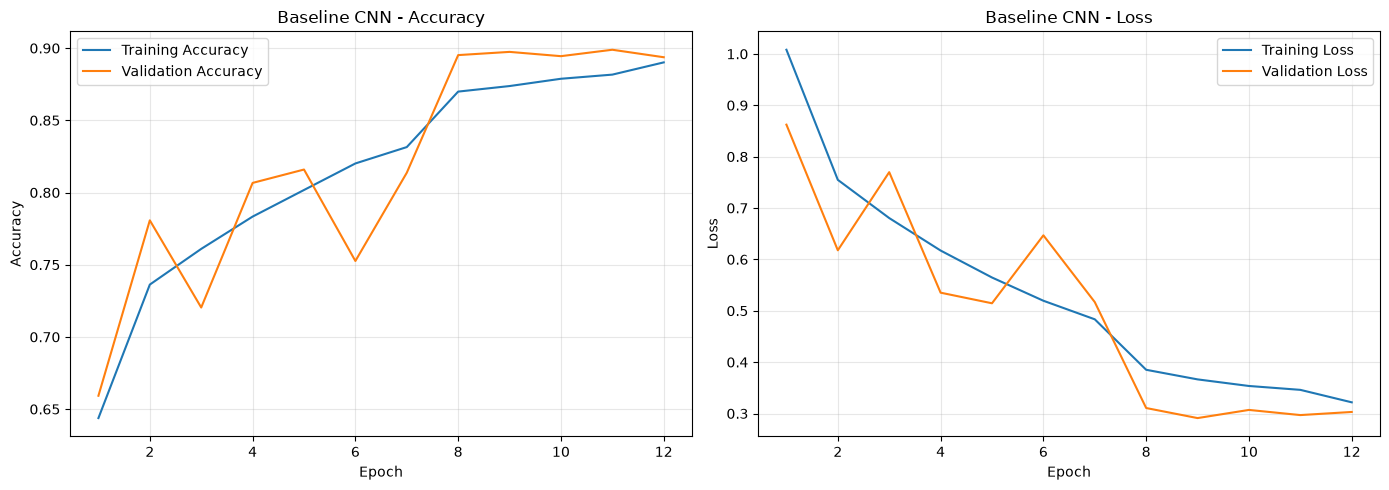

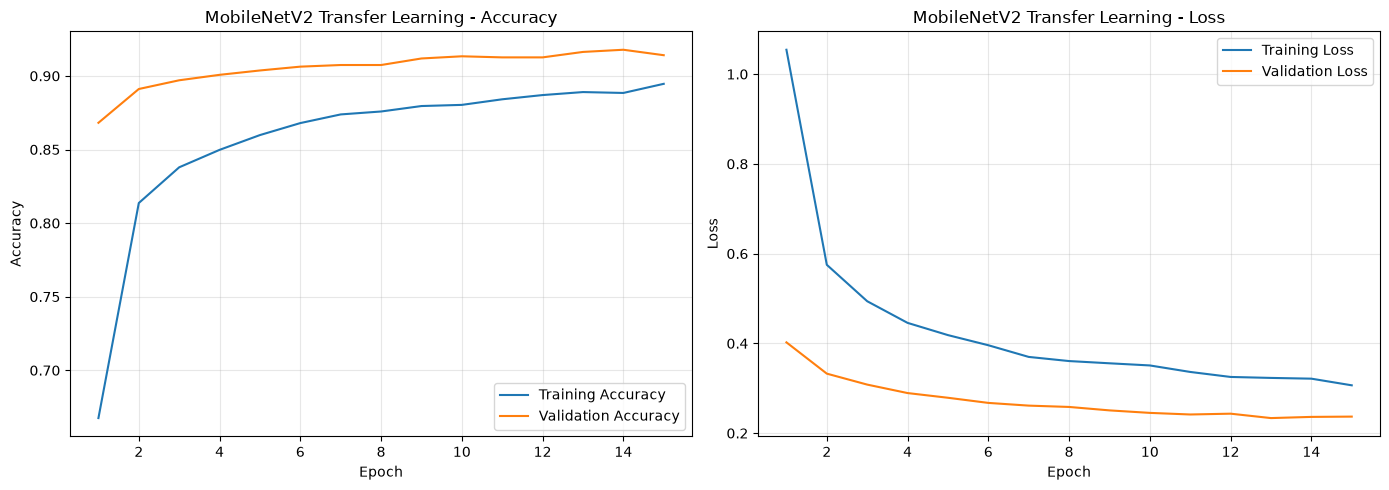

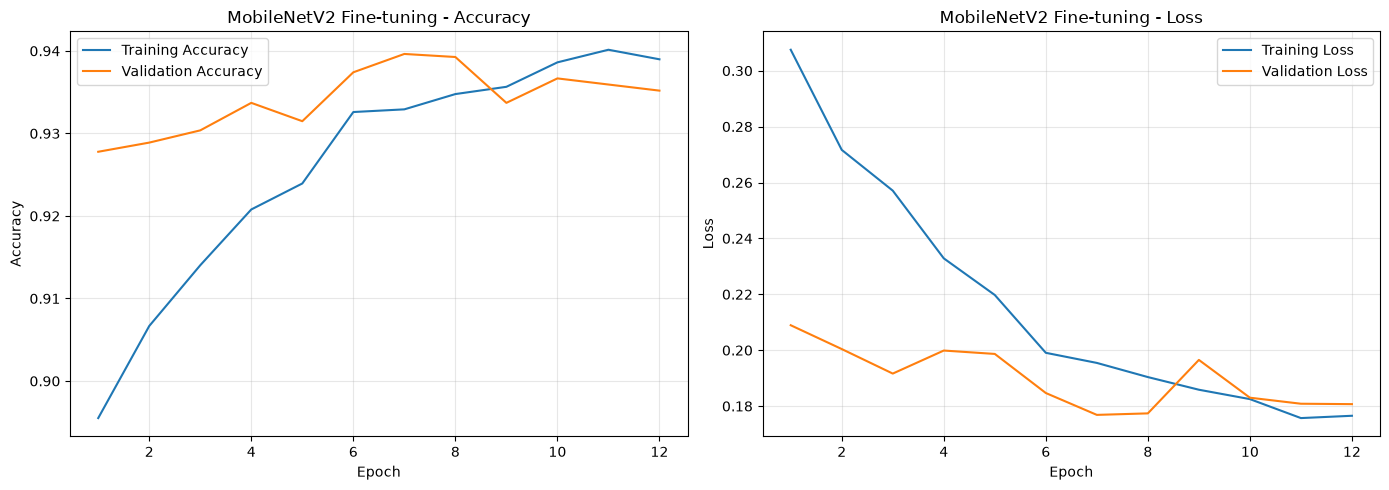

In [15]:
def plot_training_history(history: tf.keras.callbacks.History, title: str) -> None:
    history_df = pd.DataFrame(history.history)
    epochs = range(1, len(history_df) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, history_df["accuracy"], label="Training Accuracy")
    axes[0].plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history_df["loss"], label="Training Loss")
    axes[1].plot(epochs, history_df["val_loss"], label="Validation Loss")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_history(baseline_history, "Baseline CNN")
plot_training_history(transfer_history, "MobileNetV2 Transfer Learning")
plot_training_history(fine_tuned_history, "MobileNetV2 Fine-tuning")


### Analisis Singkat Training

Cell berikut merangkum best validation accuracy, validation loss terbaik, dan gap train-validation. Pemilihan kandidat untuk fase evaluasi berikutnya hanya berdasarkan validation set, bukan test set.

In [16]:
def summarize_history(history: tf.keras.callbacks.History, model_name: str) -> dict:
    history_df = pd.DataFrame(history.history)
    best_epoch_index = int(history_df["val_accuracy"].idxmax())
    best_row = history_df.loc[best_epoch_index]
    accuracy_gap = float(best_row["accuracy"] - best_row["val_accuracy"])

    if accuracy_gap > 0.10:
        fit_status = "possible_overfitting"
    elif float(best_row["val_accuracy"]) < 0.75 and float(best_row["accuracy"]) < 0.80:
        fit_status = "possible_underfitting"
    else:
        fit_status = "reasonable_fit"

    return {
        "model_name": model_name,
        "best_epoch": best_epoch_index + 1,
        "best_train_accuracy": float(best_row["accuracy"]),
        "best_validation_accuracy": float(best_row["val_accuracy"]),
        "best_validation_loss": float(best_row["val_loss"]),
        "train_validation_accuracy_gap": accuracy_gap,
        "fit_status": fit_status,
    }


training_diagnostics_df = pd.DataFrame(
    [
        summarize_history(baseline_history, "baseline_cnn"),
        summarize_history(transfer_history, "mobilenetv2_transfer_learning"),
        summarize_history(fine_tuned_history, "mobilenetv2_finetuned"),
    ]
).sort_values("best_validation_accuracy", ascending=False)

selected_model_name = training_diagnostics_df.iloc[0]["model_name"]
selected_history = {
    "baseline_cnn": baseline_history,
    "mobilenetv2_transfer_learning": transfer_history,
    "mobilenetv2_finetuned": fine_tuned_history,
}[selected_model_name]

training_diagnostics_df.to_csv(HISTORY_DIR / "training_diagnostics.csv", index=False)

print(f"Model kandidat untuk fase evaluasi: {selected_model_name}")
print("Pemilihan kandidat hanya memakai validation accuracy, bukan test set.")
training_diagnostics_df


Model kandidat untuk fase evaluasi: mobilenetv2_finetuned
Pemilihan kandidat hanya memakai validation accuracy, bukan test set.


,model_name,best_epoch,best_train_accuracy,best_validation_accuracy,best_validation_loss,train_validation_accuracy_gap,fit_status
2,mobilenetv2_finetuned,7,0.932917,0.939630,0.176862,-0.006713,reasonable_fit
1,mobilenetv2_transfer_learning,14,0.888426,0.917778,0.236198,-0.029352,reasonable_fit
0,baseline_cnn,11,0.881667,0.898889,0.296949,-0.017222,reasonable_fit


**Catatan fase 03:** model kandidat untuk fase evaluasi dipilih dari validation performance. Test set belum digunakan sama sekali untuk training, tuning, callback, atau pemilihan model. Fine-tuning MobileNetV2 meningkatkan performa dibanding transfer learning frozen, tetapi test accuracy run penuh final masih di bawah 95%. EuroSAT RGB tetap memiliki resolusi asli seragam `64x64x3`, sehingga saran resolusi tidak seragam tidak diklaim terpenuhi.


## Evaluasi dan Visualisasi

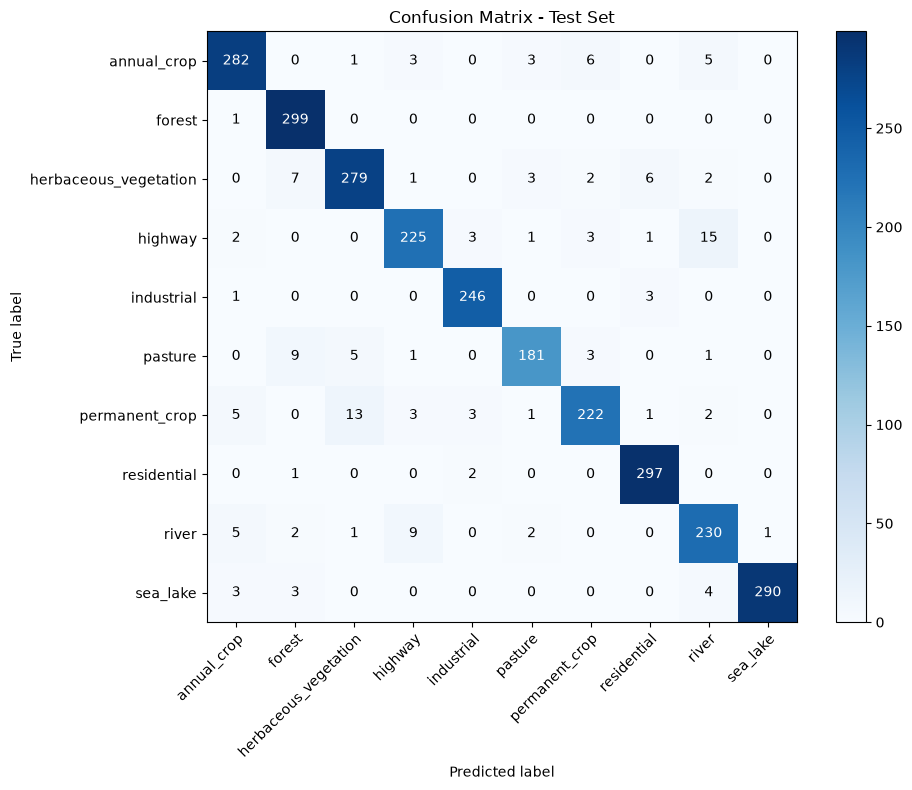

Classification report - test set:
                       precision    recall  f1-score   support

          annual_crop     0.9431    0.9400    0.9416       300
               forest     0.9315    0.9967    0.9630       300
herbaceous_vegetation     0.9331    0.9300    0.9316       300
              highway     0.9298    0.9000    0.9146       250
           industrial     0.9685    0.9840    0.9762       250
              pasture     0.9476    0.9050    0.9258       200
       permanent_crop     0.9407    0.8880    0.9136       250
          residential     0.9643    0.9900    0.9770       300
                river     0.8880    0.9200    0.9037       250
             sea_lake     0.9966    0.9667    0.9814       300

             accuracy                         0.9448      2700
            macro avg     0.9443    0.9420    0.9428      2700
         weighted avg     0.9451    0.9448    0.9446      2700



{'selected_model_name': 'mobilenetv2_finetuned',
 'checkpoint_path': 'outputs\\checkpoints\\mobilenetv2_finetuned.keras',
 'best_train_accuracy_from_training': 0.9329166412353516,
 'best_validation_accuracy_from_training': 0.9396296143531799,
 'train_loss_from_checkpoint': 0.13000629842281342,
 'train_accuracy_from_checkpoint': 0.9562036991119385,
 'validation_loss_from_checkpoint': 0.17686207592487335,
 'validation_accuracy_from_checkpoint': 0.9396296143531799,
 'test_loss': 0.17526352405548096,
 'test_accuracy': 0.9448148012161255,
 'test_samples': 2700,
 'notes': 'Test set hanya digunakan pada evaluasi akhir ini, bukan untuk training, tuning, callback, atau pemilihan model.'}

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

EVALUATION_DIR = Path("outputs") / "evaluation"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

selected_model_row = training_diagnostics_df.loc[
    training_diagnostics_df["model_name"] == selected_model_name
].iloc[0]
best_checkpoint_path = CHECKPOINT_DIR / f"{selected_model_name}.keras"
if not best_checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint model terbaik tidak ditemukan: {best_checkpoint_path}")

try:
    final_model = tf.keras.models.load_model(
        best_checkpoint_path,
        custom_objects={"preprocess_inputs": preprocess_inputs},
        safe_mode=False,
    )
except TypeError:
    final_model = tf.keras.models.load_model(
        best_checkpoint_path,
        custom_objects={"preprocess_inputs": preprocess_inputs},
    )

train_loss, train_accuracy = final_model.evaluate(train_dataset, verbose=0)
validation_loss, validation_accuracy = final_model.evaluate(validation_dataset, verbose=0)
test_loss, test_accuracy = final_model.evaluate(test_dataset, verbose=0)

y_true = []
y_pred = []
y_confidence = []

for images, labels in test_dataset:
    probabilities = final_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1).tolist())
    y_pred.extend(np.argmax(probabilities, axis=1).tolist())
    y_confidence.extend(np.max(probabilities, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
classification_report_text = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4,
)
classification_report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
)

evaluation_summary = {
    "selected_model_name": selected_model_name,
    "checkpoint_path": str(best_checkpoint_path),
    "best_train_accuracy_from_training": float(selected_model_row["best_train_accuracy"]),
    "best_validation_accuracy_from_training": float(selected_model_row["best_validation_accuracy"]),
    "train_loss_from_checkpoint": float(train_loss),
    "train_accuracy_from_checkpoint": float(train_accuracy),
    "validation_loss_from_checkpoint": float(validation_loss),
    "validation_accuracy_from_checkpoint": float(validation_accuracy),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_samples": int(len(y_true)),
    "notes": "Test set hanya digunakan pada evaluasi akhir ini, bukan untuk training, tuning, callback, atau pemilihan model.",
}

(EVALUATION_DIR / "evaluation_summary.json").write_text(
    json.dumps(evaluation_summary, indent=2),
    encoding="utf-8",
)
(EVALUATION_DIR / "classification_report.txt").write_text(
    classification_report_text,
    encoding="utf-8",
)
pd.DataFrame(classification_report_dict).transpose().to_csv(
    EVALUATION_DIR / "classification_report.csv"
)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
    EVALUATION_DIR / "confusion_matrix.csv"
)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(NUM_CLASSES),
    yticks=np.arange(NUM_CLASSES),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Confusion Matrix - Test Set",
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
threshold = cm.max() / 2
for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        ax.text(
            col_index,
            row_index,
            format(cm[row_index, col_index], "d"),
            ha="center",
            va="center",
            color="white" if cm[row_index, col_index] > threshold else "black",
        )
fig.tight_layout()
fig.savefig(EVALUATION_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Classification report - test set:")
print(classification_report_text)
evaluation_summary


## Konversi Model

Model terbaik diekspor ke SavedModel, TFLite, dan TFJS. SavedModel dan TFLite dibuat langsung dari model Keras terpilih. Untuk TFJS, package `tensorflowjs` dipasang manual dengan `--no-deps` bila perlu agar pip tidak menarik `tensorflow-decision-forests` yang dapat bentrok pada Windows/Python 3.12.


### Dependency TensorFlow.js Converter

Cell berikut mengecek ketersediaan package `tensorflowjs`. Jika belum tersedia, jangan install `tensorflowjs` biasa dari `requirements.txt` karena resolver pip dapat menarik `tensorflow-decision-forests` yang bentrok. Gunakan cell optional runtime install di bawah ini.


In [18]:
import importlib.util
import importlib.machinery
import sys
import types

TFJS_SUPPORT_INSTALL_COMMAND = (
    f'{sys.executable} -m pip install tf_keras==2.21.0 tensorflow-hub==0.16.1 '
    'jax==0.4.34 jaxlib==0.4.34 "packaging~=23.1" "setuptools<81"'
)
TFJS_INSTALL_COMMAND = f'{sys.executable} -m pip install --no-deps tensorflowjs==4.22.0'

def import_tensorflowjs_converter():
    """Import tensorflowjs untuk export; TFDF distub bila tidak tersedia."""
    if importlib.util.find_spec("tensorflow_decision_forests") is None:
        tfdf_stub = types.ModuleType("tensorflow_decision_forests")
        tfdf_stub.__spec__ = importlib.machinery.ModuleSpec("tensorflow_decision_forests", loader=None)
        sys.modules.setdefault("tensorflow_decision_forests", tfdf_stub)
    import tensorflowjs as tfjs
    return tfjs

try:
    tfjs = import_tensorflowjs_converter()
    tensorflowjs_available = True
    print(f"Package tensorflowjs tersedia: {tfjs.__version__}")
    print("Cell export TFJS dapat dijalankan.")
except ModuleNotFoundError as error:
    tensorflowjs_available = False
    print(f"Dependency TFJS belum lengkap: {error}")
    print("Jalankan dua perintah berikut, lalu restart kernel atau rerun cell dependency check:")
    print(TFJS_SUPPORT_INSTALL_COMMAND)
    print(TFJS_INSTALL_COMMAND)
except Exception as error:
    tensorflowjs_available = False
    print(f"TensorFlow.js converter belum siap: {error!r}")
    print("Coba jalankan ulang instalasi runtime berikut, lalu restart kernel:")
    print(TFJS_SUPPORT_INSTALL_COMMAND)
    print(TFJS_INSTALL_COMMAND)


Package tensorflowjs tersedia: 4.22.0
Cell export TFJS dapat dijalankan.


### Optional Runtime Install

Jalankan cell berikut hanya jika `tensorflowjs` belum tersedia di runtime aktif. Cell ini sengaja memakai `--no-deps` untuk `tensorflowjs` agar pip tidak menarik `tensorflow-decision-forests`.


In [19]:
# Optional: aktifkan dan jalankan hanya jika tensorflowjs belum tersedia.
# import sys
# !{sys.executable} -m pip install tf_keras==2.21.0 tensorflow-hub==0.16.1 jax==0.4.34 jaxlib==0.4.34 "packaging~=23.1" "setuptools<81"
# !{sys.executable} -m pip install --no-deps tensorflowjs==4.22.0


In [20]:
import contextlib
import importlib.util
import importlib.machinery
import io
import sys
import types

EXPORT_DIR = Path("outputs") / "export"
SAVED_MODEL_DIR = Path("saved_model") / "eurosat_classifier"
TFLITE_DIR = Path("tflite")
TFJS_ROOT_DIR = Path("tfjs")
TFJS_MODEL_DIR = TFJS_ROOT_DIR / "eurosat_classifier"
TFJS_TEMP_SAVED_MODEL_DIR = EXPORT_DIR / "tfjs_inference_saved_model"

for directory in [EXPORT_DIR, TFLITE_DIR, TFJS_ROOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def run_quietly(function, *args, **kwargs):
    """Jalankan export/conversion tanpa stream log yang bisa memuat path temp lokal."""
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return function(*args, **kwargs)

def clean_export_directory(directory: Path) -> None:
    if directory.exists():
        shutil.rmtree(directory)
    directory.mkdir(parents=True, exist_ok=True)


# Regenerasi export dari final_model agar artifact selalu sesuai checkpoint final.
clean_export_directory(SAVED_MODEL_DIR)
if hasattr(final_model, "export"):
    run_quietly(final_model.export, str(SAVED_MODEL_DIR))
else:
    run_quietly(tf.saved_model.save, final_model, str(SAVED_MODEL_DIR))
saved_model_created = True

label_text = "\n".join(class_names)
tflite_model_path = TFLITE_DIR / "eurosat_classifier.tflite"
converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
tflite_model = run_quietly(converter.convert)
tflite_model_path.write_bytes(tflite_model)
(TFLITE_DIR / "label.txt").write_text(label_text, encoding="utf-8")
tflite_created = True

def import_tfjs_saved_model_converter():
    """Import TFJS SavedModel converter; TFDF distub bila tidak tersedia."""
    if importlib.util.find_spec("tensorflow_decision_forests") is None:
        tfdf_stub = types.ModuleType("tensorflow_decision_forests")
        tfdf_stub.__spec__ = importlib.machinery.ModuleSpec("tensorflow_decision_forests", loader=None)
        sys.modules.setdefault("tensorflow_decision_forests", tfdf_stub)
    from tensorflowjs.converters import tf_saved_model_conversion_v2 as converter
    return converter


def build_tfjs_inference_model(trained_model: tf.keras.Model) -> tf.keras.Model:
    """Buat model inference tanpa augmentation agar TFJS graph conversion stabil."""
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
    x = inputs
    for layer in trained_model.layers[1:]:
        if layer.name == "data_augmentation":
            continue
        if isinstance(layer, tf.keras.layers.Dropout):
            x = layer(x, training=False)
        elif isinstance(layer, tf.keras.Model):
            x = layer(x, training=False)
        else:
            x = layer(x)
    return tf.keras.Model(inputs, x, name="eurosat_classifier_tfjs_inference")


def infer_tfjs_output_classes(model_json: dict) -> int | None:
    signature = model_json.get("signature") or model_json.get("modelTopology", {}).get("signature", {})
    outputs = signature.get("outputs", {})
    for output_info in outputs.values():
        dims = output_info.get("tensorShape", {}).get("dim", [])
        if dims:
            last_dim = dims[-1].get("size")
            if last_dim is not None:
                return int(last_dim)

    model_topology = model_json.get("modelTopology", model_json)
    model_config = model_topology.get("model_config", {})
    config = model_config.get("config", {})
    layers = config.get("layers", [])
    if layers:
        units = layers[-1].get("config", {}).get("units")
        if units is not None:
            return int(units)
    return None


sample_images, _ = next(iter(test_dataset.take(1)))
saved_model_loaded = tf.saved_model.load(str(SAVED_MODEL_DIR))
serving_fn = saved_model_loaded.signatures["serving_default"]
saved_model_outputs = serving_fn(tf.cast(sample_images[:1], tf.float32))
saved_model_prediction = next(iter(saved_model_outputs.values())).numpy()

interpreter = tf.lite.Interpreter(model_path=str(tflite_model_path))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.set_tensor(input_details[0]["index"], sample_images[:1].numpy().astype(input_details[0]["dtype"]))
interpreter.invoke()
tflite_prediction = interpreter.get_tensor(output_details[0]["index"])

tfjs_status = "not_exported"
tfjs_error = None
tfjs_files = []
tfjs_output_classes = None
tfjs_inference_model_max_delta = None
try:
    tfjs_inference_model = build_tfjs_inference_model(final_model)
    reference_predictions = final_model(sample_images[:2], training=False)
    tfjs_source_predictions = tfjs_inference_model(sample_images[:2], training=False)
    tfjs_inference_model_max_delta = float(
        tf.reduce_max(tf.abs(reference_predictions - tfjs_source_predictions)).numpy()
    )
    if tfjs_inference_model_max_delta > 1e-5:
        raise ValueError(
            f"Output model TFJS source berubah: max_delta={tfjs_inference_model_max_delta}"
        )

    clean_export_directory(TFJS_TEMP_SAVED_MODEL_DIR)
    clean_export_directory(TFJS_MODEL_DIR)
    if hasattr(tfjs_inference_model, "export"):
        run_quietly(tfjs_inference_model.export, str(TFJS_TEMP_SAVED_MODEL_DIR))
    else:
        run_quietly(tf.saved_model.save, tfjs_inference_model, str(TFJS_TEMP_SAVED_MODEL_DIR))

    tfjs_converter = import_tfjs_saved_model_converter()
    run_quietly(
        tfjs_converter.convert_tf_saved_model,
        str(TFJS_TEMP_SAVED_MODEL_DIR),
        str(TFJS_MODEL_DIR),
        signature_def="serving_default",
        saved_model_tags="serve",
        skip_op_check=True,
    )
    (TFJS_MODEL_DIR / "label.txt").write_text(label_text, encoding="utf-8")

    tfjs_model_json_path = TFJS_MODEL_DIR / "model.json"
    tfjs_shard_paths = sorted(TFJS_MODEL_DIR.glob("group1-shard*.bin"))
    if not tfjs_model_json_path.exists():
        raise FileNotFoundError(f"TFJS model.json tidak ditemukan: {tfjs_model_json_path}")
    if not tfjs_shard_paths:
        raise FileNotFoundError(f"TFJS shard .bin tidak ditemukan di: {TFJS_MODEL_DIR}")

    tfjs_model_json = json.loads(tfjs_model_json_path.read_text(encoding="utf-8"))
    tfjs_output_classes = infer_tfjs_output_classes(tfjs_model_json)
    if tfjs_output_classes != NUM_CLASSES:
        raise ValueError(
            f"Output TFJS tidak sesuai jumlah kelas: {tfjs_output_classes} != {NUM_CLASSES}"
        )
    if (TFJS_MODEL_DIR / "label.txt").read_text(encoding="utf-8").splitlines() != class_names:
        raise ValueError("Isi label.txt TFJS tidak sama dengan class_names.")

    tfjs_status = "exported_and_validated"
    tfjs_files = [
        {"path": str(file_path), "size_bytes": int(file_path.stat().st_size)}
        for file_path in sorted(TFJS_MODEL_DIR.glob("*"))
        if file_path.is_file()
    ]
except ModuleNotFoundError as error:
    tfjs_error = str(error)
    tfjs_status = "skipped_tensorflowjs_dependency_missing"
    print("Dependency TFJS belum lengkap. Jalankan optional runtime install TFJS di atas.")
except Exception as error:
    tfjs_error = repr(error)
    tfjs_status = "failed"

export_summary = {
    "saved_model_dir": str(SAVED_MODEL_DIR),
    "saved_model_created_in_this_run": saved_model_created,
    "tflite_model_path": str(tflite_model_path),
    "tflite_label_path": str(TFLITE_DIR / "label.txt"),
    "tflite_created_in_this_run": tflite_created,
    "tfjs_model_dir": str(TFJS_MODEL_DIR),
    "tfjs_model_json_path": str(TFJS_MODEL_DIR / "model.json"),
    "tfjs_label_path": str(TFJS_MODEL_DIR / "label.txt"),
    "tfjs_status": tfjs_status,
    "tfjs_error": tfjs_error,
    "tfjs_output_classes": tfjs_output_classes,
    "tfjs_export_format": "tfjs_graph_model_from_inference_saved_model",
    "tfjs_inference_model_max_delta": tfjs_inference_model_max_delta,
    "tfjs_files": tfjs_files,
    "saved_model_prediction_shape": list(saved_model_prediction.shape),
    "tflite_prediction_shape": list(tflite_prediction.shape),
    "saved_model_prediction_sum": float(saved_model_prediction.sum()),
    "tflite_prediction_sum": float(tflite_prediction.sum()),
}

(EXPORT_DIR / "export_summary.json").write_text(
    json.dumps(export_summary, indent=2),
    encoding="utf-8",
)
export_summary


{'saved_model_dir': 'saved_model\\eurosat_classifier',
 'saved_model_created_in_this_run': True,
 'tflite_model_path': 'tflite\\eurosat_classifier.tflite',
 'tflite_label_path': 'tflite\\label.txt',
 'tflite_created_in_this_run': True,
 'tfjs_model_dir': 'tfjs\\eurosat_classifier',
 'tfjs_model_json_path': 'tfjs\\eurosat_classifier\\model.json',
 'tfjs_label_path': 'tfjs\\eurosat_classifier\\label.txt',
 'tfjs_status': 'exported_and_validated',
 'tfjs_error': None,
 'tfjs_output_classes': 10,
 'tfjs_export_format': 'tfjs_graph_model_from_inference_saved_model',
 'tfjs_inference_model_max_delta': 0.0,
 'tfjs_files': [{'path': 'tfjs\\eurosat_classifier\\group1-shard1of3.bin',
   'size_bytes': 4194304},
  {'path': 'tfjs\\eurosat_classifier\\group1-shard2of3.bin',
   'size_bytes': 4194304},
  {'path': 'tfjs\\eurosat_classifier\\group1-shard3of3.bin',
   'size_bytes': 1138616},
  {'path': 'tfjs\\eurosat_classifier\\label.txt', 'size_bytes': 118},
  {'path': 'tfjs\\eurosat_classifier\\model.

## Inference (Optional)

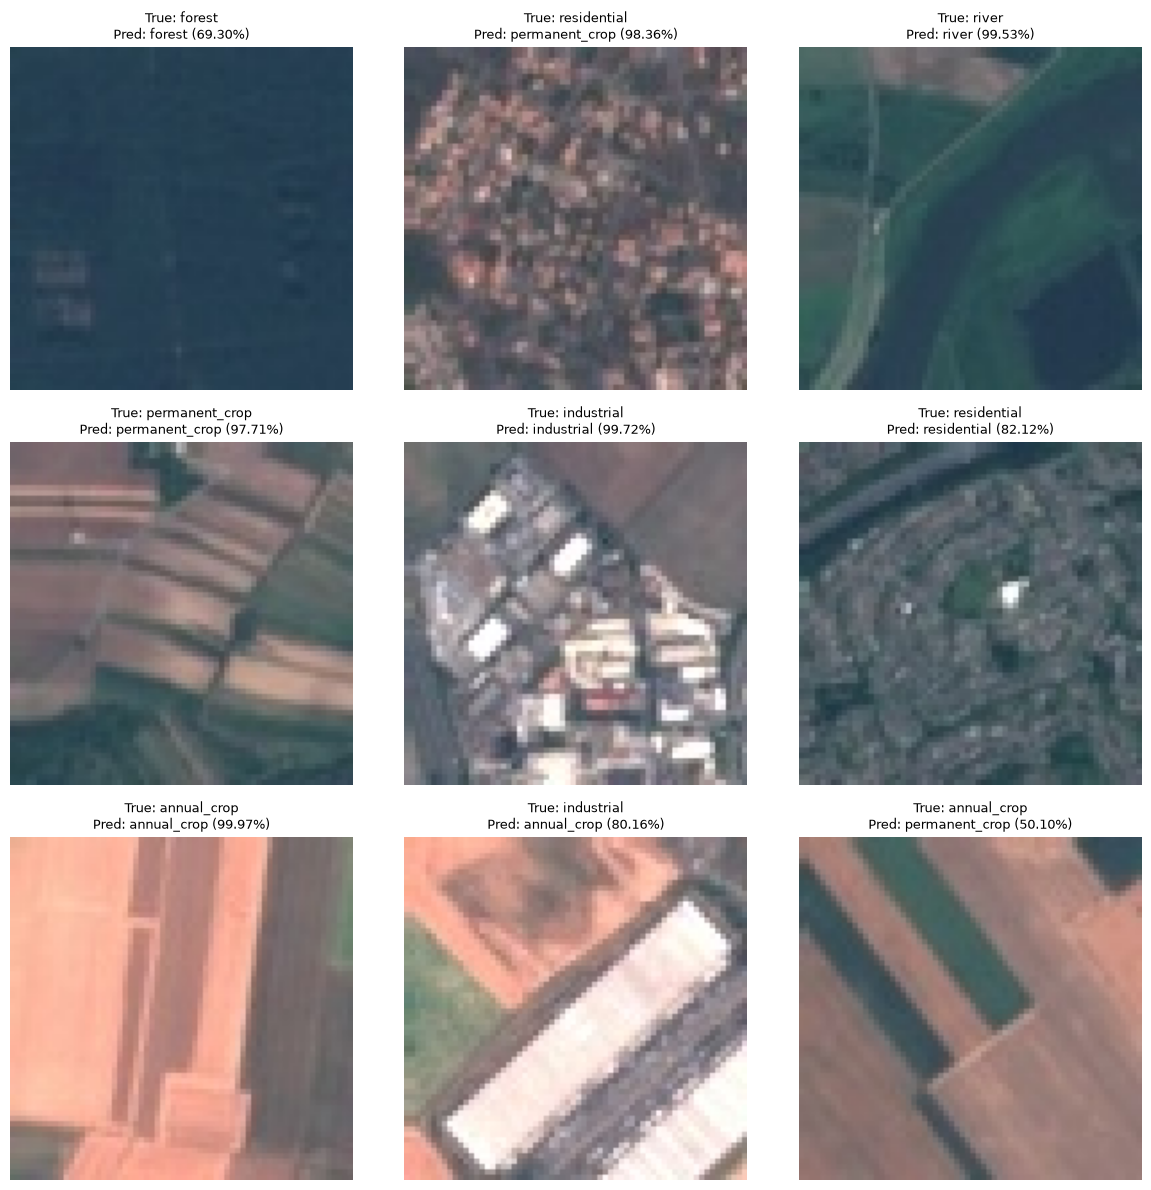

,path,true_label,predicted_label,confidence,is_correct
0,dataset\test\forest\forest_02402.jpg,forest,forest,0.693024,True
1,dataset\test\residential\residential_02375.jpg,residential,permanent_crop,0.983627,False
2,dataset\test\river\river_01649.jpg,river,river,0.995312,True
3,dataset\test\permanent_crop\permanent_crop_016...,permanent_crop,permanent_crop,0.977125,True
4,dataset\test\industrial\industrial_00327.jpg,industrial,industrial,0.997223,True
5,dataset\test\residential\residential_00199.jpg,residential,residential,0.821193,True
6,dataset\test\annual_crop\annual_crop_02315.jpg,annual_crop,annual_crop,0.999666,True
7,dataset\test\industrial\industrial_00181.jpg,industrial,annual_crop,0.801577,False
8,dataset\test\annual_crop\annual_crop_02366.jpg,annual_crop,permanent_crop,0.501029,False


In [21]:
sample_image_paths = sorted(TEST_DIR.glob("*/*.jpg"))
if not sample_image_paths:
    raise FileNotFoundError(f"Tidak ada gambar test yang ditemukan di {TEST_DIR}")

sample_count = min(9, len(sample_image_paths))
sample_rng = np.random.default_rng(SEED)
sample_indices = sample_rng.choice(len(sample_image_paths), size=sample_count, replace=False)
selected_sample_paths = [sample_image_paths[index] for index in sample_indices]

inference_rows = []
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for axis, image_path in zip(axes, selected_sample_paths):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    image_array = tf.keras.utils.img_to_array(image)
    probabilities = final_model.predict(np.expand_dims(image_array, axis=0), verbose=0)[0]

    predicted_index = int(np.argmax(probabilities))
    predicted_label = class_names[predicted_index]
    confidence = float(probabilities[predicted_index])
    true_label = image_path.parent.name

    inference_rows.append(
        {
            "path": str(image_path),
            "true_label": true_label,
            "predicted_label": predicted_label,
            "confidence": confidence,
            "is_correct": true_label == predicted_label,
        }
    )

    axis.imshow(image)
    axis.set_title(
        f"True: {true_label}\nPred: {predicted_label} ({confidence:.2%})",
        fontsize=9,
    )
    axis.axis("off")

for axis in axes[len(selected_sample_paths):]:
    axis.axis("off")

fig.tight_layout()
fig.savefig(EVALUATION_DIR / "sample_inference.png", dpi=150, bbox_inches="tight")
plt.show()

inference_examples_df = pd.DataFrame(inference_rows)
inference_examples_df.to_csv(EVALUATION_DIR / "sample_inference.csv", index=False)
inference_examples_df


## Kesimpulan

Pipeline submission ini memakai EuroSAT RGB dengan 27.000 gambar dan 10 kelas. Dataset diekspor dari TFDS, dibagi stratified 80/10/10 dengan seed 42, lalu diaudit untuk distribusi kelas, format, mode, resolusi, file corrupt, duplikasi dalam split, dan duplikasi antar split.

Model kandidat dipilih berdasarkan validation set, bukan test set. Pada run penuh final, MobileNetV2 fine-tuning menjadi kandidat terbaik berdasarkan validation accuracy. Evaluasi checkpoint final menghasilkan train accuracy sekitar 0.9562, validation accuracy sekitar 0.9396, test accuracy sekitar 0.9448, dan test loss sekitar 0.1753. Test set hanya digunakan pada bagian evaluasi akhir dan sample inference.

Artefak evaluasi disimpan di `outputs/evaluation/`, sedangkan export model final disiapkan di `saved_model/`, `tflite/`, dan `tfjs/eurosat_classifier/`. Keterbatasan yang masih ada: target saran bintang 5 untuk test accuracy 95% belum tercapai pada run penuh final, dan EuroSAT RGB memiliki resolusi asli seragam `64x64x3`, sehingga saran bintang 5 tentang resolusi asli tidak seragam tidak diklaim terpenuhi.
